In [3]:
!pip install -U albumentations scikit-image

  Using cached lazy_loader-0.4-py3-none-any.whl.metadata (7.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 23.0 MB/s eta 0:00:00 0:00:01
Using cached lazy_loader-0.4-py3-none-any.whl (12 kB)


In [4]:
from torchvision.datasets import VOCSegmentation
from torchvision.transforms.functional import to_tensor, to_pil_image
from PIL import Image
import torch
import numpy as np
from skimage.segmentation import mark_boundaries
import matplotlib.pylab as plt
from albumentations import HorizontalFlip, Compose, Resize, Normalize
import os
import time

%matplotlib inline

/opt/anaconda3/envs/ml-lecture/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
class NewVOCSegmentation(VOCSegmentation):
    def __getitem__(self, index):
        img = Image.open(self.images[index]).convert('RGB')
        target = Image.open(self.masks[index])

        if self.transforms is not None:
            augmented = self.transforms(image=np.array(img), mask=np.array(target))
            img = augmented['image']
            target = augmented['mask']
            target[target>20] = 0
        
        img = to_tensor(img)
        target = torch.from_numpy(target).type(torch.long)
        return img, target

In [ ]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
h, w = 520, 520

transform_train = Compose([
    Resize(h,w),
    HorizontalFlip(p=0.5),
    Normalize(mean=mean, std=std)
    ])

transform_val = Compose([
    Resize(h,w),
    Normalize(mean=mean, std=std)
    ])


In [10]:
!mkdir -p ./data

In [11]:
train = NewVOCSegmentation('./data', download=True, transforms=transform_train)
validate = NewVOCSegmentation('./data', download=True, image_set='val', transforms=transform_val)

100%|██████████| 2.00G/2.00G [18:04<00:00, 1.84MB/s]   


In [12]:
np.random.seed(0)
num_classes = 21
COLORS = np.random.randint(0, 2, size=(num_classes+1,3), dtype='uint8')

def show_img_target(img, target):
    if torch.is_tensor(img):
        img=to_pil_image(img)
        target=target.numpy()
    for ll in range(num_classes):
        mask=(target==ll)
        img=mark_boundaries(np.array(img),mask,outline_color=COLORS[ll],color=COLORS[ll])
    plt.imshow(img)

In [16]:
def re_normalize(x, mean=mean, std=std):
    x_r = x.clone()
    for c, (mean_c, std_c) in enumerate(zip(mean,std)):
        x_r[c] *= std_c
        x_r[c] += mean_c
    return x_r

In [17]:
img, mask = train[6]
print(img.shape, img.type(), torch.max(img))
print(mask.shape, mask.type(), torch.max(mask))

torch.Size([3, 520, 520]) torch.FloatTensor tensor(2.6400)
torch.Size([520, 520]) torch.LongTensor tensor(4)


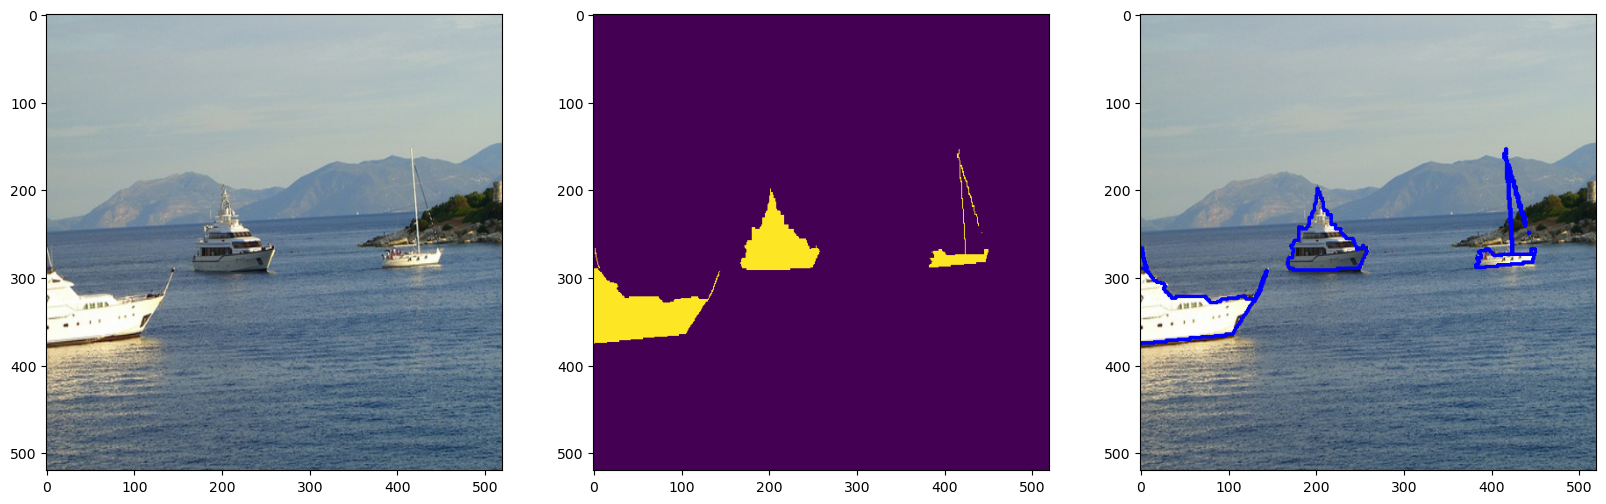

In [18]:
plt.figure(figsize=(20,20))

img_r = re_normalize(img)
plt.subplot(1,3,1)
plt.imshow(to_pil_image(img_r))

plt.subplot(1,3,2)
plt.imshow(mask)

plt.subplot(1,3,3)
show_img_target(img_r, mask)